In [1]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt

from src.IO import ExperimentLoader
from src.environment import LigandEnvironment, LogNormalConcentration
from src.physics import BinaryReceptor
from objectives.loss import ExactInformationLoss
from src import plot_latent_umap

In [2]:
# Load experiments for each n_units automatically. 
n_units_list = [5, 10, 15, 20, 30, 50]
experiments = {}

for n_units in n_units_list:
    experiment_name = f"opt_homomers_n_units_{n_units}"
    try:
        loader = ExperimentLoader(base_path="../data/", experiment_name=experiment_name)
        env, physics, loss_fn, receptor_indices, stats_df, config = loader.load_objects(filename="best_model.pt")
        experiments[n_units] = {
            'env': env,
            'physics': physics,
            'receptor_indices': receptor_indices,
            'stats_df': stats_df,
            'config': config
        }
    except FileNotFoundError:
        print(f"Experiment {experiment_name} not found. Skipping.")

Auto-discovered latest run: opt_homomers_n_units_5_20260408_141829
Auto-discovered latest run: opt_homomers_n_units_10_20260408_141850
Auto-discovered latest run: opt_homomers_n_units_15_20260408_141954
Auto-discovered latest run: opt_homomers_n_units_20_20260408_142056
Auto-discovered latest run: opt_homomers_n_units_30_20260408_142203
Auto-discovered latest run: opt_homomers_n_units_50_20260408_142324


In [11]:
experiments[10]['stats_df']

,full_array_entropy,mean_receptor_distance,lr,epoch
0,-0.0,4.538918,0.05,0
1,-0.0,4.538918,0.05,1
2,-0.0,4.538918,0.05,2
3,-0.0,4.538918,0.05,3
4,-0.0,4.538918,0.05,4
...,...,...,...,...
95,-0.0,4.538918,0.05,95
96,-0.0,4.538918,0.05,96
97,-0.0,4.538918,0.05,97
98,-0.0,4.538918,0.05,98


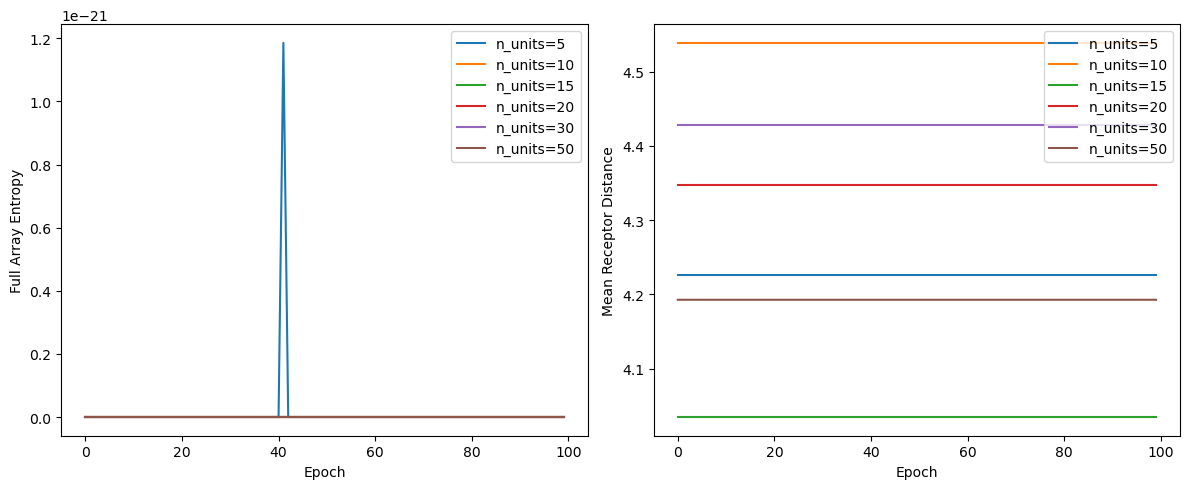

In [4]:
# Plot the training metrics for all loaded experiments
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

for n_units, exp_data in experiments.items():
    stats_df = exp_data['stats_df']
    ax[0].plot(stats_df['epoch'], stats_df['full_array_entropy'], label=f'n_units={n_units}')
    ax[1].plot(stats_df['epoch'], stats_df['mean_receptor_distance'], label=f'n_units={n_units}')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Full Array Entropy')
ax[0].legend()

ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Mean Receptor Distance')
ax[1].legend()

plt.tight_layout()
plt.show()


Fitting UMAP for n_units = 5...
Fitting UMAP... (This may take a few seconds)


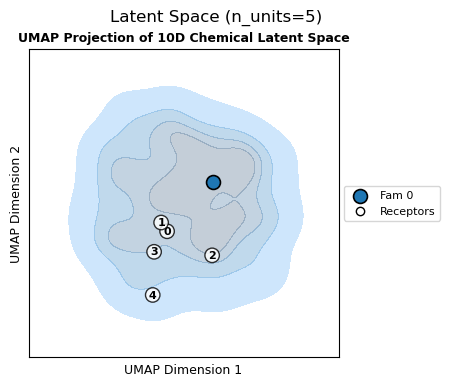


Fitting UMAP for n_units = 10...
Fitting UMAP... (This may take a few seconds)


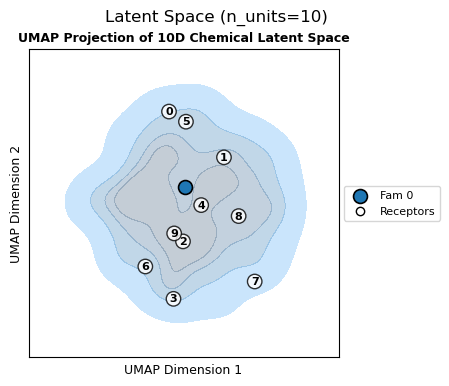


Fitting UMAP for n_units = 15...
Fitting UMAP... (This may take a few seconds)


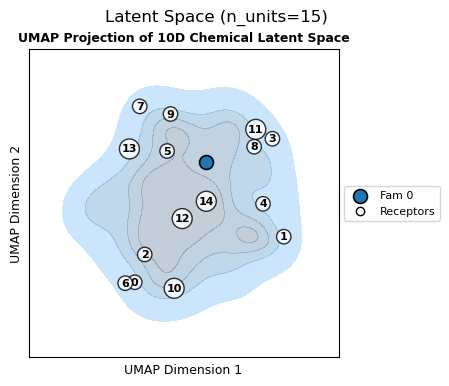


Fitting UMAP for n_units = 20...
Fitting UMAP... (This may take a few seconds)


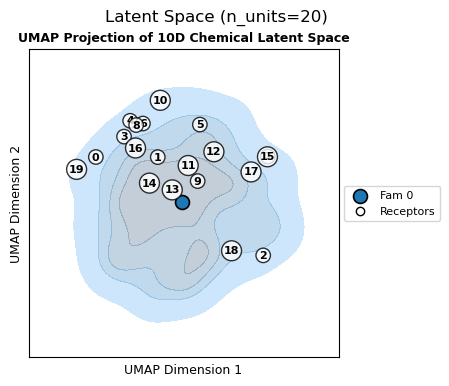


Fitting UMAP for n_units = 30...
Fitting UMAP... (This may take a few seconds)


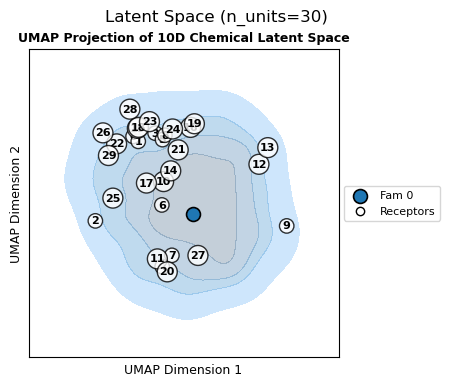


Fitting UMAP for n_units = 50...
Fitting UMAP... (This may take a few seconds)


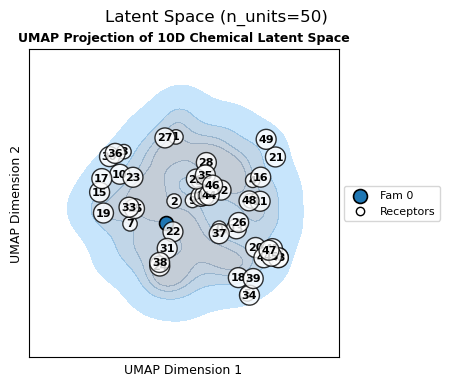

In [5]:
# Plot the latent space visualization for each experiment
for n_units, exp_data in experiments.items():
    print(f"\nFitting UMAP for n_units = {n_units}...")
    fig, ax = plot_latent_umap(exp_data['env'], exp_data['receptor_indices'])
    fig.suptitle(f"Latent Space (n_units={n_units})")
    plt.show()